In [75]:
source("/home/user/data2/lit/bin/lit_utils.R")
source("/home/user/data3/lit/project/sORFs/sORFs.utils.R")
lib_text()
lib_plot()

In [76]:
fread_c("../processed/annotation/RibORF_annot/candidate_ORFs/filtered_v3_20251103/candidateORF.filtered.rmdup.renamed.pep.extended.1.txt/augmented.2.tsv") -> all_orfs

In [77]:
nrow(all_orfs)
head(all_orfs)
colnames(all_orfs)
table(all_orfs$ORF_type)

[1] 1791601

,ORF_id,Isoform_id,Chr,Strand,ORF_type,Start_codon,Is_uniprot,Is_canonical,ORF_length,ORF_seq,⋯,N,C,A,ORF_start,ORF_end,CDS_seq,ORF_id_custom,Is_PRICE,Is_RiboCode,Is_RibORF
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<int>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<lgl>,<lgl>,<lgl>
1,PB.41013.1:chr6:+|1|330:5:44|noncoding|GTG,PB.41013.1,chr6,+,noncoding,GTG,FALSE,FALSE,12,MRAIWLRHLSPH,⋯,9918.62,224166.8,117042.7,52995623,52995662,gtgagggcgatctggctgcgacatctgtcaccccat,+chr6:52995623-52995662:MRAIWLRHLSPH,FALSE,FALSE,FALSE
2,PB.41013.1:chr6:+|2|330:16:79|noncoding|CTG,PB.41013.1,chr6,+,noncoding,CTG,FALSE,FALSE,20,MAATSVTPLIARVDSADLAG,⋯,9918.62,224166.8,117042.7,52995634,52995697,ctggctgcgacatctgtcaccccattgatcgccagggttgattcggctgatctggctggc,+chr6:52995634-52995697:MAATSVTPLIARVDSADLAG,FALSE,FALSE,FALSE
3,PB.41013.1:chr6:+|5|330:53:263|noncoding|TTG,PB.41013.1,chr6,+,noncoding,TTG,FALSE,FALSE,69,MIRLIWLARRVSPSSLTAPCASLPKLRARSKRTTIPDRGGPVFGQGYTSSCAPLLEPPNKLSRSICRRT,⋯,9918.62,224166.8,117042.7,52995671,52995881,ttgattcggctgatctggctggctaggcgggtgtccccttcctccctcaccgctccatgtgcgtccctcccgaagctgcgcgctcggtcgaagaggacgaccatccccgatagaggaggaccggtcttcggtcaagggtatacgagtagctgcgctcccctgctagaacctccaaacaagctctcaaggtccatttgtaggagaacg,+chr6:52995671-52995881:MIRLIWLARRVSPSSLTAPCASLPKLRARSKRTTIPDRGGPVFGQGYTSSCAPLLEPPNKLSRSICRRT,FALSE,FALSE,FALSE
4,PB.41013.1:chr6:+|9|330:109:166|noncoding|ATG,PB.41013.1,chr6,+,noncoding,ATG,FALSE,FALSE,18,MCVPPEAARSVEEDDHPR,⋯,9918.62,224166.8,117042.7,52995727,52995784,atgtgcgtccctcccgaagctgcgcgctcggtcgaagaggacgaccatccccga,+chr6:52995727-52995784:MCVPPEAARSVEEDDHPR,FALSE,FALSE,FALSE
5,PB.41013.1:chr6:+|10|330:111:219|noncoding|GTG,PB.41013.1,chr6,+,noncoding,GTG,FALSE,FALSE,35,MRPSRSCALGRRGRPSPIEEDRSSVKGIRVAALPC,⋯,9918.62,224166.8,117042.7,52995729,52995837,gtgcgtccctcccgaagctgcgcgctcggtcgaagaggacgaccatccccgatagaggaggaccggtcttcggtcaagggtatacgagtagctgcgctcccctgc,+chr6:52995729-52995837:MRPSRSCALGRRGRPSPIEEDRSSVKGIRVAALPC,FALSE,FALSE,FALSE
6,PB.41013.1:chr6:+|14|330:202:253|noncoding|CTG,PB.41013.1,chr6,+,noncoding,CTG,FALSE,FALSE,16,MRSPARTSKQALKVHL,⋯,9918.62,224166.8,117042.7,52995820,52995871,ctgcgctcccctgctagaacctccaaacaagctctcaaggtccatttg,+chr6:52995820-52995871:MRSPARTSKQALKVHL,FALSE,FALSE,FALSE


[1] "ORF_id"                      "Isoform_id"                 
 [3] "Chr"                         "Strand"                     
 [5] "ORF_type"                    "Start_codon"                
 [7] "Is_uniprot"                  "Is_canonical"               
 [9] "ORF_length"                  "ORF_seq"                    
[11] "Isoform_structural_category" "Isoform_subcategory"        
[13] "Geneid"                      "Gene_type"                  
[15] "RPF_reads"                   "Psites_number"              
[17] "RPF_RPKM"                    "Psites_RPKM"                
[19] "RPF_codon_coverage"          "Psites_codon_coverage"      
[21] "FL"                          "FL_TPM"                     
[23] "N"                           "C"                          
[25] "A"                           "ORF_start"                  
[27] "ORF_end"                     "CDS_seq"                    
[29] "ORF_id_custom"               "Is_PRICE"                   
[31] "Is_RiboCode"                 "Is_RibORF"


canonical      dORF      iORF noncoding     odORF     ouORF      uORF 
    22814    382695    172810   1055179     16673     26310    115120 

In [78]:
# 增加frame0的比例
fread_c("/home/user/data3/lit/project/sORFs/10-feature-egi/processed/feature_preprare/peri/psite_frame_stats.v2.tsv") -> orfs_peri
head(orfs_peri,1)

,ORF_id,CDS_nt_len,n_codons,frame0,frame1,frame2,total_psites,frame0_fraction,frame0_codon_covered
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>
1,PB.41013.1:chr6:+|1|330:5:44|noncoding|GTG,36,12,0,0,0,0,0,0


In [79]:
merge(all_orfs,orfs_peri,by="ORF_id") -> all_orfs_1
nrow(all_orfs_1)

[1] 1791601

In [80]:
# 提取Is列（排除Is_canonical）
is_cols <- c("Is_PRICE", "Is_RiboCode", "Is_RibORF")

# 计算每行TRUE的数量
n_tools <- rowSums(all_orfs_1[, is_cols] == "TRUE", na.rm = TRUE)

# 添加新列
all_orfs_1$Is_identified_by_over_1_tools <- n_tools >= 1
all_orfs_1$Is_identified_by_over_2_tools <- n_tools >= 2

all_orfs_1 %>% mutate(Is_Ribo_ORF_custom=case_when(
frame0_fraction>=0.5 & Psites_codon_coverage>=0.1 ~"TRUE",
    TRUE ~ "FALSE"
)) -> all_orfs_1

In [ ]:
filter(all_orfs_1,Is_Ribo_ORF_custom=="TRUE") -> tmp
fwrite(select(tmp,ORF_id),"../processed/annotation/RibORF_annot/candidate_ORFs/filtered_v3_20251103/compare_with_v2.orf_id.txt",col.names = F)

In [158]:
all_orfs_1 %>% filter(Geneid%in% c("TYMSOS","ZNF252P-AS1")) %>% filter(ORF_length==123 | ORF_length==211) %>% print()

                                          ORF_id Isoform_id   Chr Strand
1 PB.20235.1:chr18:-|6|851:102:474|noncoding|ATG PB.20235.1 chr18      -
2   PB.48854.2:chr8:+|1|2651:9:645|noncoding|ATG PB.48854.2  chr8      +
   ORF_type Start_codon Is_uniprot Is_canonical ORF_length
1 noncoding         ATG      FALSE        FALSE        123
2 noncoding         ATG      FALSE        FALSE        211
                                                                                                                                                                                                              ORF_seq
1                                                                                         MTPASGATASLGRLRARPRSRWDAAYLPAVAAVCVARASHVPNGTLRFGVCKARRTMRPLPGRIEVRTKRGPQRPAAPERSPQPRLPPSRHPSRRGPRRHLSGCSAPACRIPTGCRCPCGRPS
2 MLRQSCSFPVTSLPALGGVCGREGAGAEVPPAACGCEGRDPDTERSCGRSSTGGCSPCSGPGPSSPRTSRGALSPSLGRLFPHLQVVIKLRIQLAPAVHLALPTCSLLTSSPPLEGCCHRLNEEAEVQRGFRPIAVELEFENQPLGAETRLRNGRRAGVKRSEGRGQVRPGQVR

# 查看frame0_fraction>=0.5的ORF中Psites_codon_coverage的分布

In [127]:
all_orfs_1 %>% filter(frame0_fraction>=0.5) -> tmp
summary(tmp$Psites_codon_coverage)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
    0.000     0.111     0.393     8.701     2.600 17840.700 

In [130]:
all_orfs_1 %>% filter(frame0_fraction>=0.5) %>% filter(Psites_codon_coverage==0) %>% nrow()
all_orfs_1 %>% filter(frame0_fraction>=0.5) %>% filter(Psites_codon_coverage==0) %>% head() %>% print()

[1] 6126

                                          ORF_id Isoform_id   Chr Strand
1   PB.1.11:chr1:-|42|2539:556:685|noncoding|ATG    PB.1.11  chr1      -
2   PB.1.12:chr1:-|30|2507:393:756|noncoding|ATG    PB.1.12  chr1      -
3   PB.1.16:chr1:-|30|1611:393:519|noncoding|ATG    PB.1.16  chr1      -
4 PB.10022.1:chr12:+|164|4074:3091:3292|dORF|TTG PB.10022.1 chr12      +
5 PB.10022.1:chr12:+|196|4074:3848:3872|dORF|GTG PB.10022.1 chr12      +
6 PB.10022.2:chr12:+|100|3182:1623:1800|dORF|ATG PB.10022.2 chr12      +
   ORF_type Start_codon Is_uniprot Is_canonical ORF_length
1 noncoding         ATG      FALSE        FALSE         42
2 noncoding         ATG      FALSE        FALSE        120
3 noncoding         ATG      FALSE        FALSE         41
4      dORF         TTG      FALSE        FALSE         66
5      dORF         GTG      FALSE        FALSE          7
6      dORF         ATG      FALSE        FALSE         58
                                                                            

In [145]:
filter(all_orfs_1,total_psites==Psites_number) %>% nrow()
1715306/1791601

[1] 1715306

[1] 0.9574152

# 得到不同的list来进行比较

In [163]:
all_orfs_1 %>% filter(ORF_length<=150) -> all_orfs_2

In [164]:
all_orfs_2 %>% filter(ORF_type=="canonical") -> canonical_orfs
nrow(canonical_orfs)
fwrite_c(canonical_orfs,"/home/user/data3/lit/project/sORFs/10-feature-egi/processed/seve_list_compare/canonical_orfs.txt")

[1] 4506

In [ ]:
canonical_orfs.sample.2.5k <- canonical_orfs %>% filter(ORF_length<=150) %>% 
    sample_n(2500)
nrow(canonical_orfs.sample.2.5k)
fwrite_c(canonical_orfs.sample.2.5k,"/home/user/data3/lit/project/sORFs/10-feature-egi/processed/seve_list_compare/canonical_orfs.sample.2.5k.lt.150aa.txt")

[1] 2500

In [167]:
sum(canonical_orfs.sample.2.5k$Is_Ribo_ORF_custom=="TRUE")

[1] 2165

In [107]:
all_orfs_2 %>% filter(Gene_type=="lncRNA")  -> tmp
nrow(tmp)
head(tmp)
n_distinct(tmp$Geneid)
tmp %>% 
    group_by(Geneid) %>% 
    slice_sample(n = 1) %>%
    ungroup() -> lnc_orfs
head(lnc_orfs$Geneid)
fwrite_c(lnc_orfs,"/home/user/data3/lit/project/sORFs/10-feature-egi/processed/seve_list_compare/lnc_orfs.txt")

[1] 153797

,ORF_id,Isoform_id,Chr,Strand,ORF_type,Start_codon,Is_uniprot,Is_canonical,ORF_length,ORF_seq,⋯,n_codons,frame0,frame1,frame2,total_psites,frame0_fraction,frame0_codon_covered,Is_identified_by_over_1_tools,Is_identified_by_over_2_tools,Is_Ribo_ORF_custom
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<int>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<lgl>,<lgl>,<chr>
1,PB.100.1:chr1:-|108|2138:1369:1435|noncoding|CTG,PB.100.1,chr1,-,noncoding,CTG,FALSE,FALSE,21,MLLPTPPACRPLSAGLLLLRG,⋯,21,0,0,0,0,0.000000,0,FALSE,FALSE,FALSE
2,PB.100.1:chr1:-|112|2138:1406:1469|noncoding|GTG,PB.100.1,chr1,-,noncoding,GTG,FALSE,FALSE,20,MLGCSSSEDERGNNPVGRGC,⋯,20,0,0,0,0,0.000000,0,FALSE,FALSE,FALSE
3,PB.100.1:chr1:-|115|2138:1431:1491|noncoding|ATG,PB.100.1,chr1,-,noncoding,ATG,FALSE,FALSE,19,MSVGITQWGEDADGAMDVH,⋯,19,0,0,0,0,0.000000,0,FALSE,FALSE,FALSE
4,PB.100.1:chr1:-|117|2138:1462:1777|noncoding|ATG,PB.100.1,chr1,-,noncoding,ATG,FALSE,FALSE,104,MLTAPWMSTEGPRWARPSSVLWSQISFKPSSTSHFTRGKVGESGSESRVSHGGAAGLRCEPYSLPMSRTPGLDTPEPSQAAFLGLPEHLAGCCWSGTLDGGPGS,⋯,104,0,0,0,0,0.000000,0,FALSE,FALSE,FALSE
5,PB.100.1:chr1:-|12|2138:156:525|noncoding|GTG,PB.100.1,chr1,-,noncoding,GTG,FALSE,FALSE,122,MERGPHGLAGAGCFSPLDACGGGDGRASDTARGSLSGYFSHPAKLLETSKETRPVSTQASGKCRPPVWELSSPLLTHRSALTHRDGEWGSSSAAFHRQRGHIPFQQSLWPRCLRLRGQPACG,⋯,122,3,17,1,21,0.142857,2,FALSE,FALSE,FALSE
6,PB.100.1:chr1:-|122|2138:1500:1545|noncoding|ATG,PB.100.1,chr1,-,noncoding,ATG,FALSE,FALSE,14,MGQAELCALESDLI,⋯,14,0,0,0,0,0.000000,0,FALSE,FALSE,FALSE


[1] 2420

[1] "ABR-AS1"     "ADAMTS16-DT" "ADAMTS9-AS1" "ADAMTS9-AS2" "ADGRA1-AS1" 
[6] "ADGRB3-DT"

In [162]:
sum(lnc_orfs$Is_Ribo_ORF_custom=="TRUE")
sum(lnc_orfs$Is_identified_by_over_1_tools)

[1] 217

[1] 54

In [149]:
table(all_orfs_2$ORF_type)
table(all_orfs_2$Is_Ribo_ORF_custom,all_orfs_2$ORF_type)
table(all_orfs_2$Is_identified_by_over_1_tools,all_orfs_2$ORF_type)
table(all_orfs_2$Is_identified_by_over_2_tools,all_orfs_2$ORF_type)


canonical      dORF      iORF noncoding     odORF     ouORF      uORF 
     4506    381825    171897   1041304     16050     25235    114316 

       
        canonical   dORF   iORF noncoding  odORF  ouORF   uORF
  FALSE       616 342451 168336    977632  15052  21932  89644
  TRUE       3890  39374   3561     63672    998   3303  24672

       
        canonical    dORF    iORF noncoding   odORF   ouORF    uORF
  FALSE       900  378487  171498   1028415   15867   23569  105084
  TRUE       3606    3338     399     12889     183    1666    9232

       
        canonical    dORF    iORF noncoding   odORF   ouORF    uORF
  FALSE      1496  381209  171837   1034986   15992   24551  110369
  TRUE       3010     616      60      6318      58     684    3947

In [150]:
filter(all_orfs_2,Is_Ribo_ORF_custom=="TRUE") -> all_orfs_3
table(all_orfs_3$Is_identified_by_over_1_tools,all_orfs_3$ORF_type)
table(all_orfs_3$Is_identified_by_over_2_tools,all_orfs_3$ORF_type)

       
        canonical  dORF  iORF noncoding odORF ouORF  uORF
  FALSE       457 36311  3280     51664   841  2036 16090
  TRUE       3433  3063   281     12008   157  1267  8582

       
        canonical  dORF  iORF noncoding odORF ouORF  uORF
  FALSE       895 38779  3507     57504   940  2674 20802
  TRUE       2995   595    54      6168    58   629  3870

# Other

In [30]:
fread_c("/home/user/data3/lit/project/sORFs/01-ribo-seq/analysis/20251022_custom_fa_gtf/processed/orfs/organized/PRICE/nonCano.sorf.tab") -> PIRCE_orfs
n_distinct(PIRCE_orfs$V2)
sum(PIRCE_orfs$V2 %in% all_orfs$ORF_seq)

[1] 18038

[1] 3638

# cutoff可视化

In [121]:
nrow(all_orfs_1)
table(all_orfs_1$ORF_type)
filter(all_orfs_1,Is_Ribo_ORF_custom=="TRUE") %>% count(ORF_type)
21860/22814
sum(all_orfs_1$Is_Ribo_ORF_custom=="TRUE")
sum(all_orfs_2$Is_identified_by_over_1_tools)
sum(all_orfs_2$Is_identified_by_over_2_tools)

[1] 1791601


canonical      dORF      iORF noncoding     odORF     ouORF      uORF 
    22814    382695    172810   1055179     16673     26310    115120 

ORF_type,n
<chr>,<int>
canonical,21860
dORF,39544
iORF,3561
noncoding,73264
odORF,1059
ouORF,3385
uORF,24864


[1] 0.9581836

[1] 167537

[1] 31313

[1] 14693

In [113]:
colnames(all_orfs_1)

[1] "ORF_id"                        "Isoform_id"                   
 [3] "Chr"                           "Strand"                       
 [5] "ORF_type"                      "Start_codon"                  
 [7] "Is_uniprot"                    "Is_canonical"                 
 [9] "ORF_length"                    "ORF_seq"                      
[11] "Isoform_structural_category"   "Isoform_subcategory"          
[13] "Geneid"                        "Gene_type"                    
[15] "RPF_reads"                     "Psites_number"                
[17] "RPF_RPKM"                      "Psites_RPKM"                  
[19] "RPF_codon_coverage"            "Psites_codon_coverage"        
[21] "FL"                            "FL_TPM"                       
[23] "N"                             "C"                            
[25] "A"                             "ORF_start"                    
[27] "ORF_end"                       "CDS_seq"                      
[29] "ORF_id_custom"                 "Is_PRICE"                     
[31] "Is_RiboCode"                   "Is_RibORF"                    
[33] "CDS_nt_len"                    "n_codons"                     
[35] "frame0"                        "frame1"                       
[37] "frame2"                        "total_psites"                 
[39] "frame0_fraction"               "frame0_codon_covered"         
[41] "Is_identified_by_over_1_tools" "Is_identified_by_over_2_tools"
[43] "Is_Ribo_ORF_custom"

In [137]:
library(ggplot2)
library(dplyr)
library(patchwork)

# 准备数据：创建三个独立的数据集
# 组1: Canonical ORFs
canonical_data <- all_orfs_1 %>%
    filter(ORF_type == "canonical") %>%
    mutate(Group = "Canonical")

# 组2: Identified by 1+ tools
tools_data <- all_orfs_1 %>%
    filter(Is_identified_by_over_1_tools == TRUE) %>%
    mutate(Group = "Identified by 1+ tools")

# 组3: 随机采样3万个ORF
set.seed(123)  # 设置随机种子以保证结果可重复
sampled_data <- all_orfs_1 %>%
    sample_n(min(30000, nrow(all_orfs_1))) %>%  # 如果总数不足3万，则全部采样
    mutate(Group = "Sampled (30k)")

# 合并三组数据（允许重复）
plot_data <- bind_rows(canonical_data, tools_data, sampled_data)

# 检查数据
cat("各组数据量:\n")
cat("Canonical:", nrow(canonical_data), "\n")
cat("Identified by 1+ tools:", nrow(tools_data), "\n")
cat("Sampled (30k):", nrow(sampled_data), "\n")
cat("总行数（包含重叠）:", nrow(plot_data), "\n\n")

各组数据量:
Canonical: 22814 
Identified by 1+ tools: 57259 
Sampled (30k): 30000 
总行数（包含重叠）: 110073 



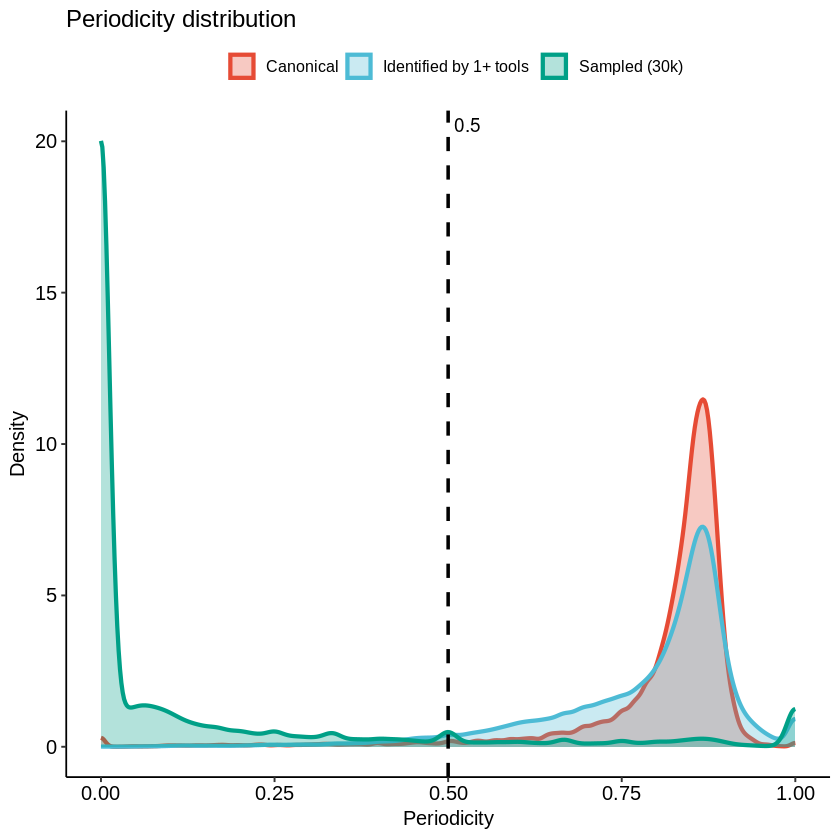

In [146]:
# 图2: frame0_fraction 叠加密度图
p2 <- ggplot(plot_data, aes(x = frame0_fraction, 
                             color = Group, fill = Group)) +
    geom_density(alpha = 0.3, size = 1.2) +
    geom_vline(xintercept = 0.5, linetype = "dashed", 
               color = "black", size = 1) +
    annotate("text", x = 0.5, y = Inf, 
             label = "0.5", 
             hjust = -0.2, vjust = 1.5, size = 4) +
    scale_color_manual(
        values = c("Canonical" = "#E64B35", 
                   "Identified by 1+ tools" = "#4DBBD5",
                   "Sampled (30k)" = "#00A087"),
        name = ""
    ) +
    scale_fill_manual(
        values = c("Canonical" = "#E64B35", 
                   "Identified by 1+ tools" = "#4DBBD5",
                   "Sampled (30k)" = "#00A087"),
        name = ""
    ) +
    labs(
        x = "Periodicity",
        y = "Density",
        title = "Periodicity distribution"
    ) +
    theme_3()
p2

Warning message:
“Removed 40153 rows containing non-finite outside the scale range
(`stat_density()`).”


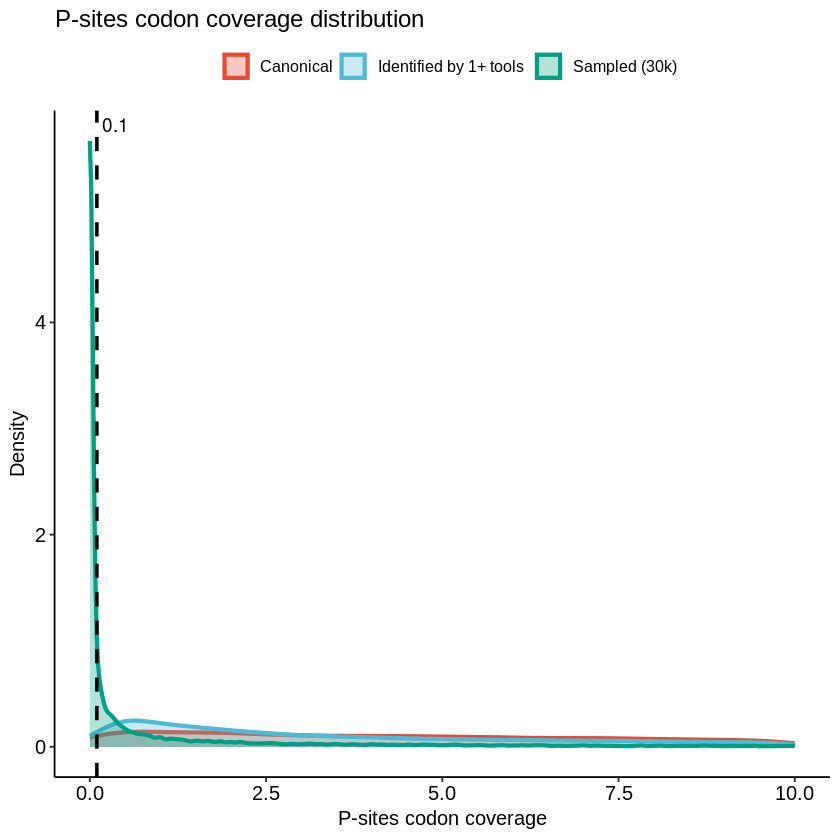

In [147]:
# 图1: Psites_codon_coverage 叠加密度图
p1 <- ggplot(plot_data, aes(x = Psites_codon_coverage, 
                             color = Group, fill = Group)) +
    geom_density(alpha = 0.3, size = 1.2) +
    geom_vline(xintercept = 0.1, linetype = "dashed", 
               color = "black", size = 1) +
    annotate("text", x = 0.1, y = Inf, 
             label = "0.1", 
             hjust = -0.2, vjust = 1.5, size = 4) +
    scale_color_manual(
        values = c("Canonical" = "#E64B35", 
                   "Identified by 1+ tools" = "#4DBBD5",
                   "Sampled (30k)" = "#00A087"),
        name = ""
    ) +
    scale_fill_manual(
        values = c("Canonical" = "#E64B35", 
                   "Identified by 1+ tools" = "#4DBBD5",
                   "Sampled (30k)" = "#00A087"),
        name = ""
    ) +
    labs(
        x = "P-sites codon coverage",
        y = "Density",
        title = "P-sites codon coverage distribution"
    ) +
    theme_3()+
xlim(0,10)
p1